# Kapitel 5 — Ergebnisse FF2: Interdependenzen und zeitliche Manifestation

**Forschungsfrage 2:** Wie haengen die Dynamikmuster verschiedener Kennzahlen zusammen, und wie manifestieren sie sich in Krisenphasen?

Die Analyse erweitert FF1 um zwei Dimensionen. Erstens werden die in Kap. 4 geschaetzten Mean-Reversion-Staerken phi1 und Volatilitaeten sigma kennzahluebergreifend korreliert (Querschnitt). Zweitens werden die Volatilitaeten ueber die Zeit verfolgt, um Reaktionen auf Krisenphasen quartalsgenau zu identifizieren. Beide Perspektiven stuetzen sich vollstaendig auf die AR(1)-Schaetzungen aus FF1; es werden keine neuen Modelle eingefuehrt.


In [1]:
# Setup
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

import analysis_helpers as ah
from analysis_helpers import (
    RATIO_ORDER, RATIO_LABEL, RATIO_LAYER, SECTOR_ORDER,
)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})

LAYER_COLORS = {
    'Profitabilität':   '#2C5F8D',
    'Liquidität':       '#7FB069',
    'Kapitalstruktur':  '#C75D4F',
}
QUAD_COLORS = {
    'KORREKTIV-STABIL':   '#1F77B4',
    'KORREKTIV-VOLATIL':  '#D62728',
    'PERSISTENT-STABIL':  '#2CA02C',
    'PERSISTENT-VOLATIL': '#FF7F0E',
}

# Bonferroni-Schwelle fuer FF2: 21 phi1-Paare + 21 sigma-Paare = 42 Tests
ALPHA_FAMILY = 0.05
N_TESTS_FF2 = 42
BONF_THRESH = ALPHA_FAMILY / N_TESTS_FF2

print(f'Setup OK. Bonferroni-Schwelle FF2: alpha = {BONF_THRESH:.6f} '
      f'({ALPHA_FAMILY}/{N_TESTS_FF2}).')


Setup OK. Bonferroni-Schwelle FF2: alpha = 0.001190 (0.05/42).


---
## 5.1 Querschnittliche Interdependenz

Die Korrelationsanalyse pruelt, ob Unternehmen mit hoher Mean-Reversion in einer Kennzahl auch in anderen Kennzahlen schnell zum Mittel zurueckkehren, und analog fuer die Volatilitaet. Verwendet wird Spearmans Rangkorrelation (robust gegen Ausreisser, keine Normalitaetsannahme). Familienweise Fehlerkontrolle erfolgt per Bonferroni-Korrektur ueber alle 42 Paartests (21 phi1 + 21 sigma).


### 5.1.1 phi1-Korrelationsmatrix


In [2]:
# Korrelationsmatrix der Mean-Reversion-Staerken
corr_phi1 = ah.load_corr_matrix('phi1')
corr_phi1 = corr_phi1.reindex(index=RATIO_ORDER, columns=RATIO_ORDER)
corr_phi1.round(3)


,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
ratio,,,,,,,
ROA,1.000,0.779,0.558,0.192,0.085,0.079,0.084
ROE,0.779,1.000,0.541,0.148,0.087,0.080,0.126
EBIT_margin,0.558,0.541,1.000,0.140,0.005,0.024,0.083
fcf_margin,0.192,0.148,0.140,1.000,0.065,0.015,0.080
current_ratio,0.085,0.087,0.005,0.065,1.000,0.057,0.163
debt_to_equity,0.079,0.080,0.024,0.015,0.057,1.000,0.335
equity_ratio,0.084,0.126,0.083,0.080,0.163,0.335,1.000


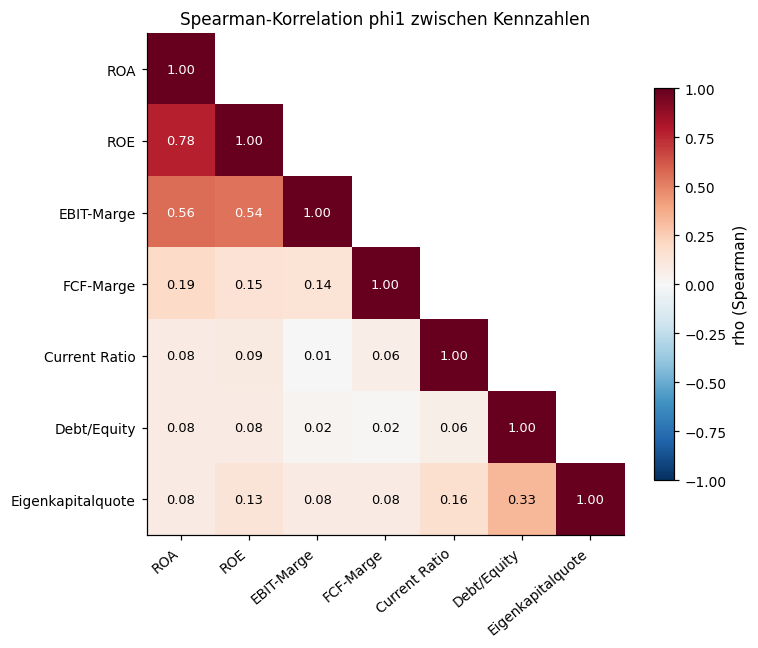

In [3]:
# Heatmap phi1-Korrelation
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_phi1, dtype=bool), k=1)
vals = corr_phi1.where(~mask)
im = ax.imshow(vals, cmap='RdBu_r', vmin=-1.0, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(RATIO_ORDER)))
ax.set_yticks(range(len(RATIO_ORDER)))
ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=40, ha='right')
ax.set_yticklabels([RATIO_LABEL[r] for r in RATIO_ORDER])
for i in range(len(RATIO_ORDER)):
    for j in range(len(RATIO_ORDER)):
        if i >= j:
            v = corr_phi1.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8.5, color='black' if abs(v) < 0.4 else 'white')
ax.set_title('Spearman-Korrelation phi1 zwischen Kennzahlen')
fig.colorbar(im, ax=ax, shrink=0.78, label='rho (Spearman)')
plt.tight_layout()
plt.show()


### 5.1.2 sigma-Korrelationsmatrix


In [4]:
corr_sigma = ah.load_corr_matrix('sigma')
corr_sigma = corr_sigma.reindex(index=RATIO_ORDER, columns=RATIO_ORDER)
corr_sigma.round(3)


,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
ratio,,,,,,,
ROA,1.000,0.772,0.511,0.279,0.227,0.282,0.524
ROE,0.772,1.000,0.416,0.237,0.020,0.664,0.391
EBIT_margin,0.511,0.416,1.000,0.663,0.401,0.203,0.224
fcf_margin,0.279,0.237,0.663,1.000,0.447,0.215,0.187
current_ratio,0.227,0.020,0.401,0.447,1.000,0.037,0.376
debt_to_equity,0.282,0.664,0.203,0.215,0.037,1.000,0.385
equity_ratio,0.524,0.391,0.224,0.187,0.376,0.385,1.000


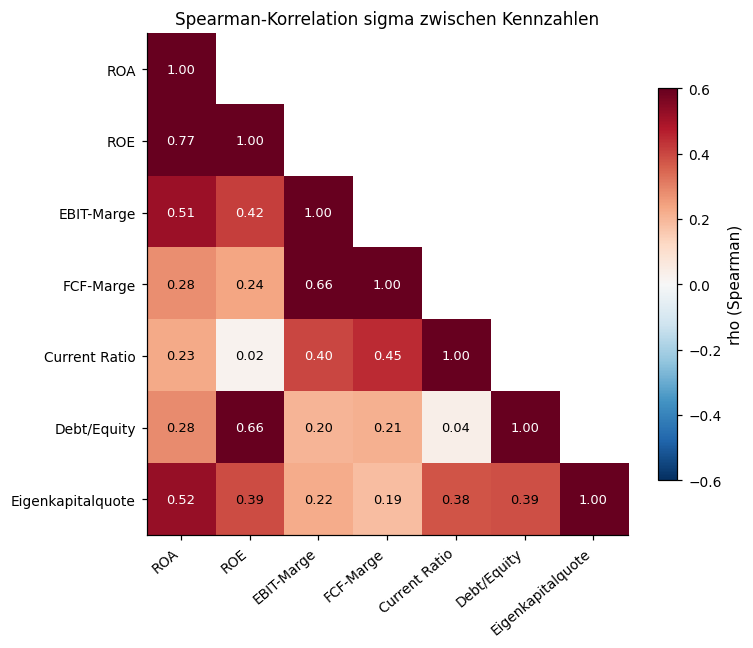

In [5]:
# Heatmap sigma-Korrelation
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_sigma, dtype=bool), k=1)
vals = corr_sigma.where(~mask)
im = ax.imshow(vals, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(RATIO_ORDER)))
ax.set_yticks(range(len(RATIO_ORDER)))
ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=40, ha='right')
ax.set_yticklabels([RATIO_LABEL[r] for r in RATIO_ORDER])
for i in range(len(RATIO_ORDER)):
    for j in range(len(RATIO_ORDER)):
        if i >= j:
            v = corr_sigma.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8.5, color='black' if abs(v) < 0.4 else 'white')
ax.set_title('Spearman-Korrelation sigma zwischen Kennzahlen')
fig.colorbar(im, ax=ax, shrink=0.78, label='rho (Spearman)')
plt.tight_layout()
plt.show()


### 5.1.3 Bonferroni-Korrektur (alpha = 0,05/42)

Nominell signifikante Paare bei alpha=0,05 und nach Bonferroni-Korrektur (alpha/42 = 0,00119). Die Long-Form-Tabellen zeigen jeden Paartest einmal.


In [6]:
# Long-Form mit Bonferroni-Markierung
phi1_long = ah.load_pval_long('phi1').sort_values('p_value').reset_index(drop=True)
sigma_long = ah.load_pval_long('sigma').sort_values('p_value').reset_index(drop=True)

n_phi_05 = phi1_long['significant_05'].sum()
n_phi_bonf = phi1_long['significant_bonferroni'].sum()
n_sig_05 = sigma_long['significant_05'].sum()
n_sig_bonf = sigma_long['significant_bonferroni'].sum()

summary = pd.DataFrame({
    'Matrix': ['phi1', 'sigma'],
    'Tests gesamt': [len(phi1_long), len(sigma_long)],
    'p < 0,05': [n_phi_05, n_sig_05],
    'p < 0,05/42 (Bonferroni)': [n_phi_bonf, n_sig_bonf],
})
summary


,Matrix,Tests gesamt,"p < 0,05","p < 0,05/42 (Bonferroni)"
0,phi1,21,18,9
1,sigma,21,19,18


In [7]:
# Volle Long-Form-Tabelle phi1 (sortiert nach p-Wert)
phi1_long.assign(p_value=phi1_long['p_value'].round(6))


,ratio_a,ratio_b,p_value,significant_05,significant_bonferroni
0,ROA,ROE,0.000000,True,True
1,current_ratio,equity_ratio,0.000000,True,True
2,ROE,EBIT_margin,0.000000,True,True
3,debt_to_equity,equity_ratio,0.000000,True,True
4,ROA,fcf_margin,0.000000,True,True
5,ROA,EBIT_margin,0.000000,True,True
6,ROE,fcf_margin,0.000001,True,True
7,EBIT_margin,fcf_margin,0.000002,True,True
8,current_ratio,debt_to_equity,0.001053,True,True
9,ROE,equity_ratio,0.003748,True,False


In [8]:
# Volle Long-Form-Tabelle sigma (sortiert nach p-Wert)
sigma_long.assign(p_value=sigma_long['p_value'].round(6))


,ratio_a,ratio_b,p_value,significant_05,significant_bonferroni
0,ROA,ROE,0.000000,True,True
1,fcf_margin,equity_ratio,0.000000,True,True
2,fcf_margin,current_ratio,0.000000,True,True
3,EBIT_margin,equity_ratio,0.000000,True,True
4,EBIT_margin,debt_to_equity,0.000000,True,True
5,EBIT_margin,current_ratio,0.000000,True,True
6,EBIT_margin,fcf_margin,0.000000,True,True
7,current_ratio,equity_ratio,0.000000,True,True
8,ROE,debt_to_equity,0.000000,True,True
9,ROE,equity_ratio,0.000000,True,True


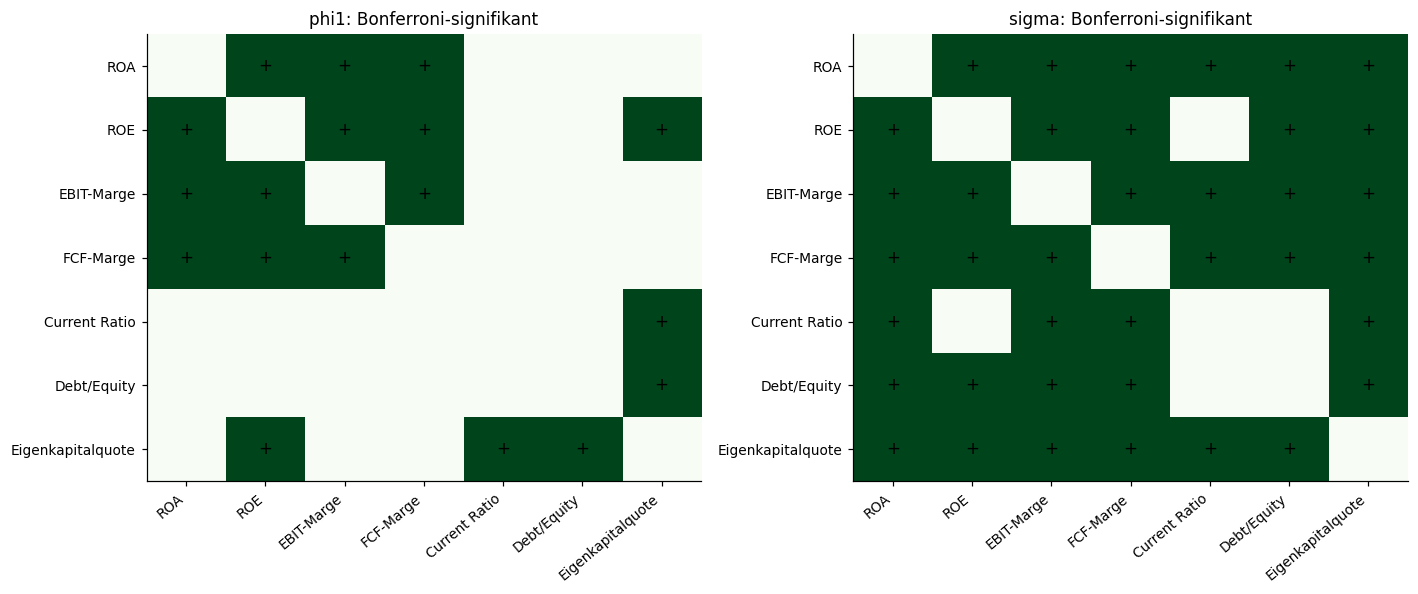

In [9]:
# Heatmap Bonferroni-Signifikanz: 1 = signifikant, 0 = nicht
sig_phi = pd.read_csv(ah._csv('output/interdependence/sig_bonferroni_phi1.csv'),
                       index_col=0).reindex(index=RATIO_ORDER, columns=RATIO_ORDER)
sig_sig = pd.read_csv(ah._csv('output/interdependence/sig_bonferroni_sigma.csv'),
                       index_col=0).reindex(index=RATIO_ORDER, columns=RATIO_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, mat, title in [
    (axes[0], sig_phi.astype(int), 'phi1: Bonferroni-signifikant'),
    (axes[1], sig_sig.astype(int), 'sigma: Bonferroni-signifikant'),
]:
    ax.imshow(mat, cmap='Greens', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(RATIO_ORDER)))
    ax.set_yticks(range(len(RATIO_ORDER)))
    ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=40, ha='right')
    ax.set_yticklabels([RATIO_LABEL[r] for r in RATIO_ORDER])
    for i in range(len(RATIO_ORDER)):
        for j in range(len(RATIO_ORDER)):
            if i != j:
                ax.text(j, i, '+' if mat.iloc[i, j] else '',
                        ha='center', va='center', fontsize=11)
    ax.set_title(title)
plt.tight_layout()
plt.show()


### 5.1.4 Sektor-spezifische Spearman-Korrelation

Pruefung, ob die in 5.1.1 gefundenen Interdependenzen sektorinvariant sind oder bestimmten Sektoren ihre Auspraegung verdanken. Pro Sektor wird die Spearman-Korrelationsmatrix der phi1-Werte separat berechnet (mindestens 30 Unternehmen je Kennzahl-Paar als Stabilitaetskriterium). Aufgrund der hoeheren Anzahl Tests (10 Sektoren x 21 Paare = 210) wird hier die nominelle 5%-Schwelle ohne Bonferroni gezeigt; markante Abweichungen vom Aggregat aus 5.1.1 sind das primaere Interesse.


In [10]:
# Sektor-spezifische phi1-Korrelationen
ar = ah.load_ar_features()
ar = ah.attach_sector(ar)

# Wide: ticker x ratio mit phi1-Wert
phi_wide = ar.pivot_table(index=['ticker', 'sector'], columns='ratio',
                           values='phi1').reset_index()

sectors_avail = [s for s in SECTOR_ORDER if (phi_wide['sector'] == s).sum() >= 30]
print(f'Sektoren mit n>=30 Tickern: {len(sectors_avail)}')
print('Listen:', sectors_avail)


Sektoren mit n>=30 Tickern: 10
Listen: ['Industrials', 'Consumer Cyclical', 'Technology', 'Healthcare', 'Utilities', 'Consumer Defensive', 'Basic Materials', 'Real Estate', 'Energy', 'Communication Services']


In [11]:
def sector_corr_matrix(df_wide: pd.DataFrame, sector: str) -> pd.DataFrame:
    sub = df_wide[df_wide['sector'] == sector][RATIO_ORDER]
    return sub.corr(method='spearman')

sector_corrs = {s: sector_corr_matrix(phi_wide, s) for s in sectors_avail}
print(f'{len(sector_corrs)} Sektor-Korrelationsmatrizen berechnet.')


10 Sektor-Korrelationsmatrizen berechnet.


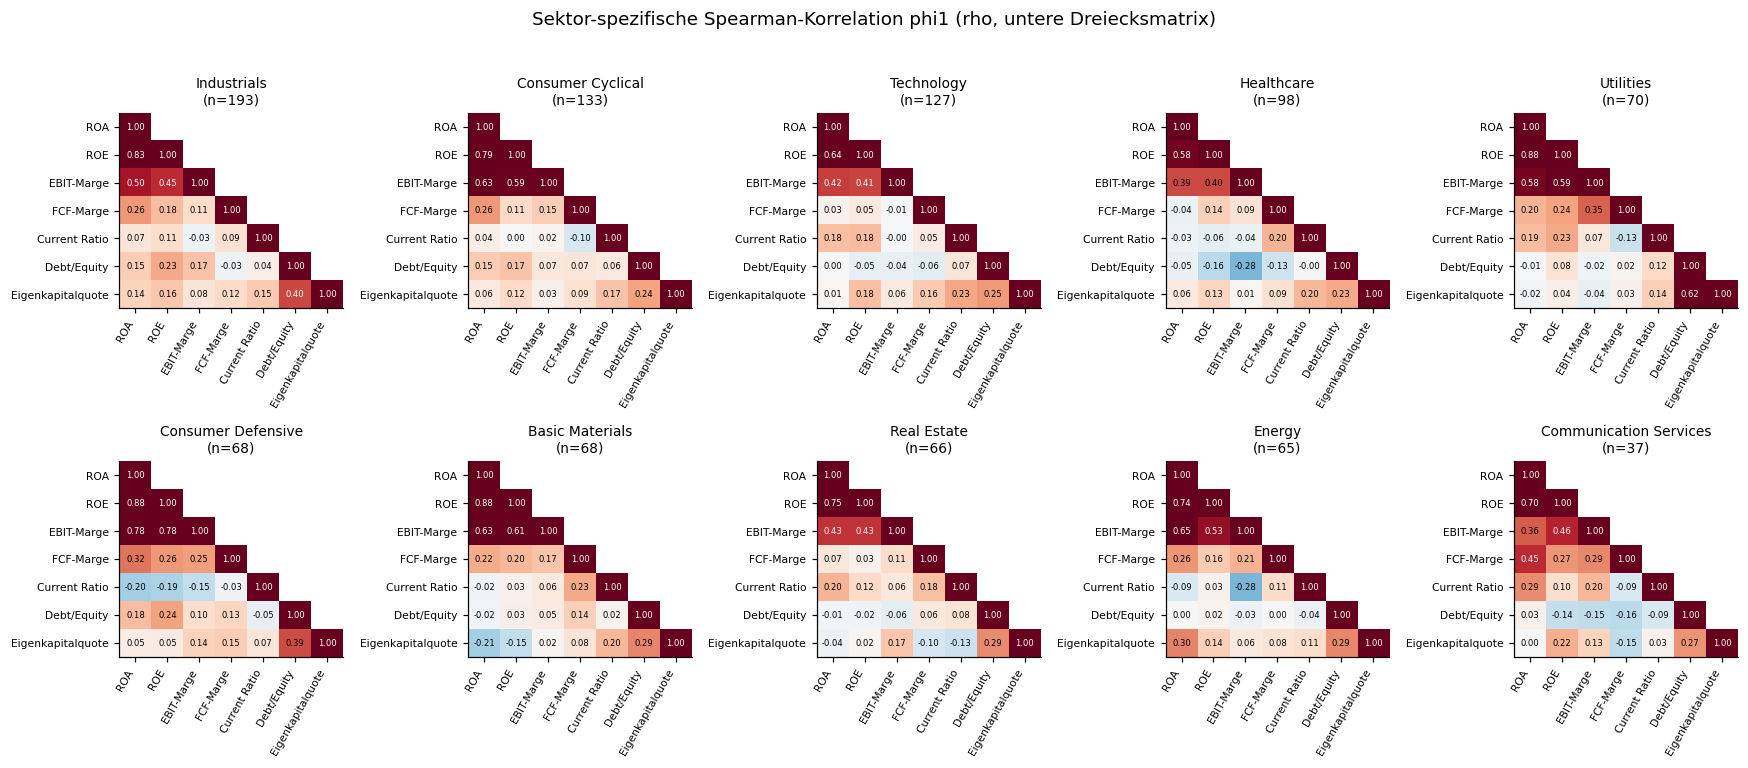

In [12]:
# Grid-Heatmap: 2 Zeilen x 5 Spalten, mit Werten in den Kaestchen
n = len(sectors_avail)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.4),
                          squeeze=False)
for idx, sector in enumerate(sectors_avail):
    ax = axes[idx // ncols][idx % ncols]
    cm = sector_corrs[sector].reindex(index=RATIO_ORDER, columns=RATIO_ORDER)
    mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
    vals = cm.where(~mask)
    ax.imshow(vals, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
    n_tick = (phi_wide['sector'] == sector).sum()
    ax.set_title(f'{sector}\n(n={n_tick})', fontsize=9)
    ax.set_xticks(range(len(RATIO_ORDER)))
    ax.set_yticks(range(len(RATIO_ORDER)))
    ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER],
                       rotation=60, ha='right', fontsize=7)
    ax.set_yticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], fontsize=7)
    # Werte in die Kaestchen
    for i in range(len(RATIO_ORDER)):
        for j in range(len(RATIO_ORDER)):
            if i >= j:
                v = cm.iloc[i, j]
                if pd.notna(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=5.5,
                            color='black' if abs(v) < 0.4 else 'white')
# leere Achsen abschalten
for k in range(n, nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Sektor-spezifische Spearman-Korrelation phi1 (rho, untere Dreiecksmatrix)',
              y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# Tabelle: pro Kennzahl-Paar Median und Spannweite der Sektor-rho-Werte
rows = []
for a, b in combinations(RATIO_ORDER, 2):
    rhos = [sector_corrs[s].loc[a, b] for s in sectors_avail
             if pd.notna(sector_corrs[s].loc[a, b])]
    if not rhos:
        continue
    rhos = pd.Series(rhos)
    rows.append({
        'Paar': f'{RATIO_LABEL[a]} - {RATIO_LABEL[b]}',
        'rho_aggregat': round(corr_phi1.loc[a, b], 3),
        'rho_sektor_median': round(rhos.median(), 3),
        'rho_sektor_min': round(rhos.min(), 3),
        'rho_sektor_max': round(rhos.max(), 3),
        'spannweite': round(rhos.max() - rhos.min(), 3),
    })
sektor_phi_summary = pd.DataFrame(rows).sort_values('spannweite', ascending=False)
sektor_phi_summary.reset_index(drop=True)


,Paar,rho_aggregat,rho_sektor_median,rho_sektor_min,rho_sektor_max,spannweite
0,ROA - Eigenkapitalquote,0.084,0.028,-0.206,0.299,0.505
1,ROA - Current Ratio,0.085,0.056,-0.202,0.286,0.488
2,ROA - FCF-Marge,0.192,0.241,-0.039,0.446,0.485
3,EBIT-Marge - Current Ratio,0.005,0.008,-0.277,0.199,0.476
4,EBIT-Marge - Debt/Equity,0.024,-0.029,-0.276,0.170,0.445
5,ROA - EBIT-Marge,0.558,0.536,0.363,0.785,0.422
6,ROE - Current Ratio,0.087,0.065,-0.189,0.229,0.418
7,ROE - Debt/Equity,0.080,0.027,-0.162,0.239,0.402
8,Debt/Equity - Eigenkapitalquote,0.335,0.287,0.228,0.622,0.394
9,ROE - EBIT-Marge,0.541,0.495,0.398,0.782,0.385


#### Sektor-Abweichungen vom Aggregat (Sektor x Paar-Heatmap)

Pro Kennzahl-Paar (a, b) wird die Differenz `delta_rho = rho_sektor - rho_aggregat` berechnet. Rot = Sektor zeigt staerkeren Zusammenhang als das Aggregat, Blau = schwaecheren bzw. gegenlaeufigen. So wird sektor-zentriert sichtbar, welche Branchen den globalen Spearman-Wert systematisch verzerren.


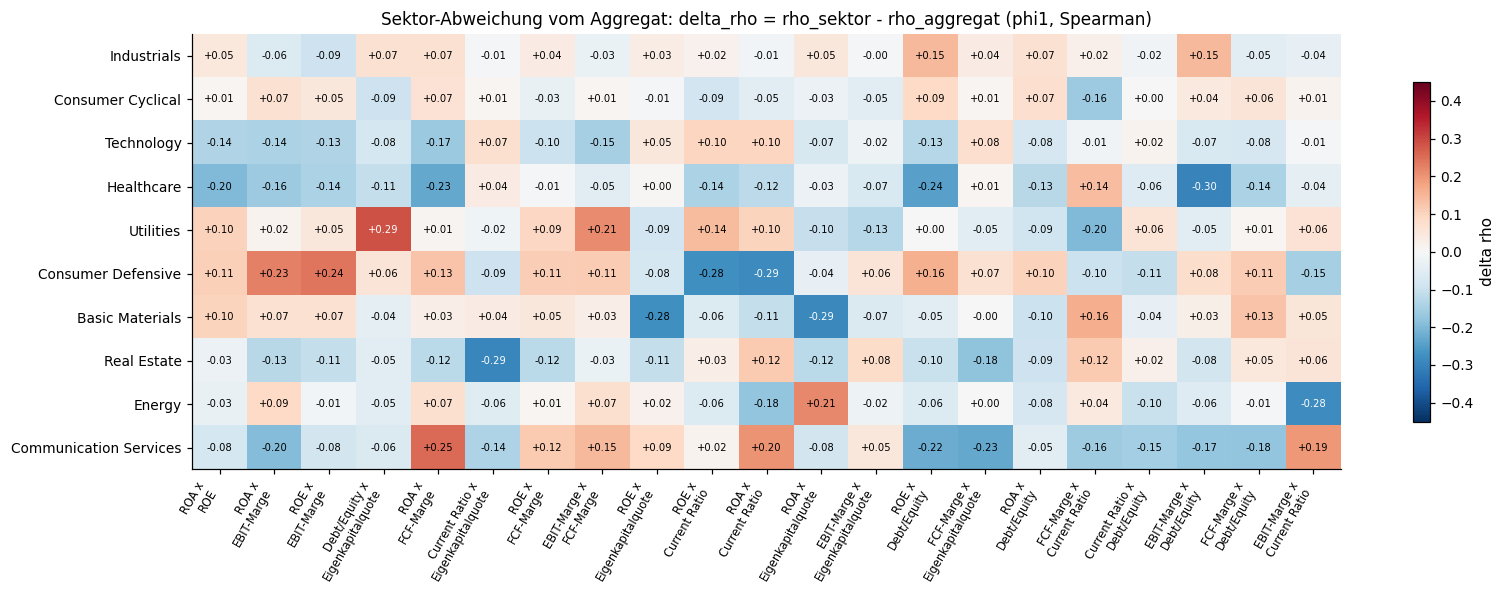

In [14]:
# Sektor x Paar Heatmap der Abweichungen vom Aggregat-rho
pair_labels = []
delta_matrix = []  # Sektoren als Zeilen, Paare als Spalten

# Paare nach Aggregat-rho absteigend sortieren (lesbarer)
pair_list = sorted(combinations(RATIO_ORDER, 2),
                   key=lambda ab: -corr_phi1.loc[ab[0], ab[1]])

for s in sectors_avail:
    row = []
    sub = phi_wide[phi_wide['sector'] == s]
    for a, b in pair_list:
        pair = sub[[a, b]].dropna()
        if len(pair) >= 30:
            rho_s = pair[a].rank().corr(pair[b].rank())
            row.append(rho_s - corr_phi1.loc[a, b])
        else:
            row.append(np.nan)
    delta_matrix.append(row)

pair_labels = [f'{RATIO_LABEL[a]} x\n{RATIO_LABEL[b]}' for a, b in pair_list]
delta_df = pd.DataFrame(delta_matrix, index=sectors_avail, columns=pair_labels)

# Heatmap
fig, ax = plt.subplots(figsize=(15, 5.5))
im = ax.imshow(delta_df, cmap='RdBu_r', vmin=-0.45, vmax=0.45, aspect='auto')
ax.set_xticks(range(len(pair_labels)))
ax.set_yticks(range(len(sectors_avail)))
ax.set_xticklabels(pair_labels, rotation=60, ha='right', fontsize=7.5)
ax.set_yticklabels(sectors_avail, fontsize=9)
for i in range(len(sectors_avail)):
    for j in range(len(pair_labels)):
        v = delta_df.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    fontsize=6.5, color='black' if abs(v) < 0.28 else 'white')
ax.set_title('Sektor-Abweichung vom Aggregat: delta_rho = rho_sektor - rho_aggregat (phi1, Spearman)')
fig.colorbar(im, ax=ax, shrink=0.78, label='delta rho')
plt.tight_layout()
plt.show()


In [15]:
# Zeilen-Aggregat: pro Sektor die mittlere |delta_rho| und Anzahl starker Abweichungen
abs_delta = delta_df.abs()
sektor_summary = pd.DataFrame({
    'mean_abs_delta_rho': abs_delta.mean(axis=1).round(3),
    'max_abs_delta_rho':  abs_delta.max(axis=1).round(3),
    'paare_mit_|d|>0.15': (abs_delta > 0.15).sum(axis=1).astype(int),
    'paare_mit_|d|>0.30': (abs_delta > 0.30).sum(axis=1).astype(int),
    'n_ticker':           [(phi_wide['sector'] == s).sum() for s in sectors_avail],
}).sort_values('mean_abs_delta_rho', ascending=False)
sektor_summary


,mean_abs_delta_rho,max_abs_delta_rho,paare_mit_|d|>0.15,paare_mit_|d|>0.30,n_ticker
Communication Services,0.137,0.254,10,0,37
Consumer Defensive,0.128,0.287,6,0,68
Healthcare,0.112,0.300,5,0,98
Real Estate,0.097,0.293,2,0,66
Utilities,0.089,0.287,3,0,70
Technology,0.085,0.166,1,0,127
Basic Materials,0.085,0.290,3,0,68
Energy,0.072,0.282,3,0,65
Industrials,0.050,0.147,0,0,193
Consumer Cyclical,0.048,0.164,1,0,133


### 5.1.5 Lead-Lag-Analyse (Skeleton)

Die zeitliche Vorlauf/Nachlauf-Beziehung zwischen den Kennzahl-Differenzen delta Y_t fuer Lags k = -4 ... +4 ist ein eigenstaendiger Analyse-Block. Die Spezifikation liegt in `Text/E6.1_Lead_Lag_Spezifikation.md`. Implementiert wird sie in einer Folgesession in `src/lead_lag.py`. Der vorbereitete Slot im Notebook laedt die Output-Datei sobald sie existiert; bis dahin wird die Spezifikation als Hinweis ausgegeben.


In [16]:
# E6.1 Lead-Lag — Slot fuer kuenftige Implementierung
ll_path = ah._csv('output/interdependence/lead_lag_aggregated.csv')
if ll_path.exists():
    ll = pd.read_csv(ll_path)
    print(f'Lead-Lag-Tabelle geladen: {len(ll)} Zeilen')
    display(ll.head(20))
else:
    print('TODO E6.1: Lead-Lag-Implementierung steht aus.')
    print('Spec: Text/E6.1_Lead_Lag_Spezifikation.md')
    print('Erwartete Output-Datei: output/interdependence/lead_lag_aggregated.csv')


TODO E6.1: Lead-Lag-Implementierung steht aus.
Spec: Text/E6.1_Lead_Lag_Spezifikation.md
Erwartete Output-Datei: output/interdependence/lead_lag_aggregated.csv


### 5.1.6 Quadranten-Crosstabs zwischen Kennzahlen

Wenn ein Unternehmen in Kennzahl A in Quadrant Q liegt, in welcher Wahrscheinlichkeit liegt es in Kennzahl B im gleichen Quadranten? Pro Kennzahl-Paar wird die 4x4-Quadranten-Crosstab und der zugehoerige chi^2-Test (alpha = 0,05/21) berechnet. Cramers V wird nicht ausgewiesen (vgl. Methodikentscheidung E11), die rohen Zellfrequenzen sind fuer die inhaltliche Diskussion ausreichend.


In [17]:
# Quadranten pro Ticker x Kennzahl
quad_df = ah.compute_quadrants(ar)
qpivot = quad_df.pivot_table(index='ticker', columns='ratio',
                              values='quadrant', aggfunc='first')
qpivot = qpivot.reindex(columns=RATIO_ORDER)
print(f'Quadranten-Pivot: {qpivot.shape[0]} Ticker x {qpivot.shape[1]} Kennzahlen')
qpivot.head()


Quadranten-Pivot: 932 Ticker x 7 Kennzahlen


ratio,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
ticker,,,,,,,
A,KORREKTIV-VOLATIL,KORREKTIV-VOLATIL,PERSISTENT-VOLATIL,KORREKTIV-VOLATIL,PERSISTENT-VOLATIL,PERSISTENT-STABIL,KORREKTIV-STABIL
AAL,PERSISTENT-VOLATIL,KORREKTIV-VOLATIL,PERSISTENT-VOLATIL,PERSISTENT-VOLATIL,PERSISTENT-STABIL,KORREKTIV-VOLATIL,PERSISTENT-VOLATIL
AAON,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-STABIL,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,KORREKTIV-VOLATIL
AAP,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL,PERSISTENT-STABIL
AAPL,PERSISTENT-VOLATIL,PERSISTENT-VOLATIL,PERSISTENT-STABIL,PERSISTENT-STABIL,PERSISTENT-STABIL,KORREKTIV-STABIL,KORREKTIV-STABIL


In [18]:
# 4x4 Crosstab + chi^2 pro Paar (alpha = 0,05/21 fuer 21 Paare)
QUAD_LABELS = ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL',
                'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']
alpha_pair = 0.05 / 21
rows = []
for a, b in combinations(RATIO_ORDER, 2):
    sub = qpivot[[a, b]].dropna()
    if len(sub) < 30:
        continue
    ct = pd.crosstab(sub[a], sub[b]).reindex(index=QUAD_LABELS, columns=QUAD_LABELS,
                                                fill_value=0)
    chi2_v, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({
        'Paar': f'{RATIO_LABEL[a]} - {RATIO_LABEL[b]}',
        'n': int(ct.values.sum()),
        'chi2': round(chi2_v, 1),
        'dof': dof,
        'p_value': p,
        'sig_05': p < 0.05,
        'sig_bonf_21': p < alpha_pair,
    })
crosstab_summary = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
crosstab_summary.assign(p_value=crosstab_summary['p_value'].apply(lambda x: f'{x:.2e}'))


,Paar,n,chi2,dof,p_value,sig_05,sig_bonf_21
0,ROA - ROE,931,900.3,9,5.39e-188,True,True
1,ROA - EBIT-Marge,931,306.4,9,1.16e-60,True,True
2,EBIT-Marge - FCF-Marge,932,256.3,9,4.65e-50,True,True
3,ROE - EBIT-Marge,931,248.6,9,1.92e-48,True,True
4,ROE - Debt/Equity,931,242.5,9,3.88e-47,True,True
5,Debt/Equity - Eigenkapitalquote,931,175.5,9,4.40e-33,True,True
6,ROA - Eigenkapitalquote,931,134.6,9,1.34e-24,True,True
7,ROE - Eigenkapitalquote,931,122.8,9,3.56e-22,True,True
8,Current Ratio - Eigenkapitalquote,932,104.4,9,2.04e-18,True,True
9,FCF-Marge - Current Ratio,932,92.2,9,5.79e-16,True,True


In [19]:
# Beispiel-Crosstab: ROA x ROE (rohe Zellzaehlungen)
sub = qpivot[['ROA', 'ROE']].dropna()
ct_roa_roe = pd.crosstab(sub['ROA'], sub['ROE']).reindex(
    index=QUAD_LABELS, columns=QUAD_LABELS, fill_value=0)
ct_roa_roe.index.name = 'ROA -> '
ct_roa_roe.columns.name = 'ROE'
ct_roa_roe


ROE,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ROA ->,,,,
KORREKTIV-STABIL,152,40,18,13
KORREKTIV-VOLATIL,45,146,4,47
PERSISTENT-STABIL,24,8,181,30
PERSISTENT-VOLATIL,3,45,39,136


In [20]:
# Beispiel-Crosstab: Current Ratio x Debt/Equity (rohe Zellzaehlungen)
sub = qpivot[['current_ratio', 'debt_to_equity']].dropna()
ct_cr_de = pd.crosstab(sub['current_ratio'], sub['debt_to_equity']).reindex(
    index=QUAD_LABELS, columns=QUAD_LABELS, fill_value=0)
ct_cr_de.index.name = 'Current Ratio -> '
ct_cr_de.columns.name = 'Debt/Equity'
ct_cr_de


Debt/Equity,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
Current Ratio ->,,,,
KORREKTIV-STABIL,46,56,49,49
KORREKTIV-VOLATIL,53,95,64,53
PERSISTENT-STABIL,63,64,86,53
PERSISTENT-VOLATIL,38,50,67,45


---
## 5.2 Zeitliche Manifestation: Event-Analyse

Die Volatilitaet der Kennzahl-Differenzen wird quartalsgenau auf das gesamte Panel berechnet. Im Mittelpunkt stehen Spitzen ueber dem 95-Perzentil pro Kennzahl, also Quartale mit aussergewoehnlich grosser Querschnittsstreuung. In einem zweiten Schritt werden die Reaktionen pro Quadrant und Sektor um die identifizierten Peak-Quartale herum verglichen.


### 5.2.1 Volatilitaets-Timeline


In [21]:
# Volatilitaets-Score pro Kennzahl x Quartal
vol = pd.read_csv(ah._csv('output/explore/volatility_scores.csv'))
vol['quarter_dt'] = pd.PeriodIndex(vol['quarter'], freq='Q').to_timestamp()
print(f'Volatilitaets-Datensatz: {len(vol)} Zeilen, '
      f'{vol["ratio"].nunique()} Kennzahlen, '
      f'{vol["quarter"].nunique()} Quartale')
vol.head()


Volatilitaets-Datensatz: 700 Zeilen, 7 Kennzahlen, 100 Quartale


,ratio,quarter,vol_score,vol_percentile,is_peak,quarter_dt
0,ROA,2000Q1,0.004584,6.0,False,2000-01-01
1,ROA,2000Q2,0.004790,20.0,False,2000-04-01
2,ROA,2000Q3,0.005163,51.0,False,2000-07-01
3,ROA,2000Q4,0.005818,86.0,False,2000-10-01
4,ROA,2001Q1,0.006050,91.0,False,2001-01-01


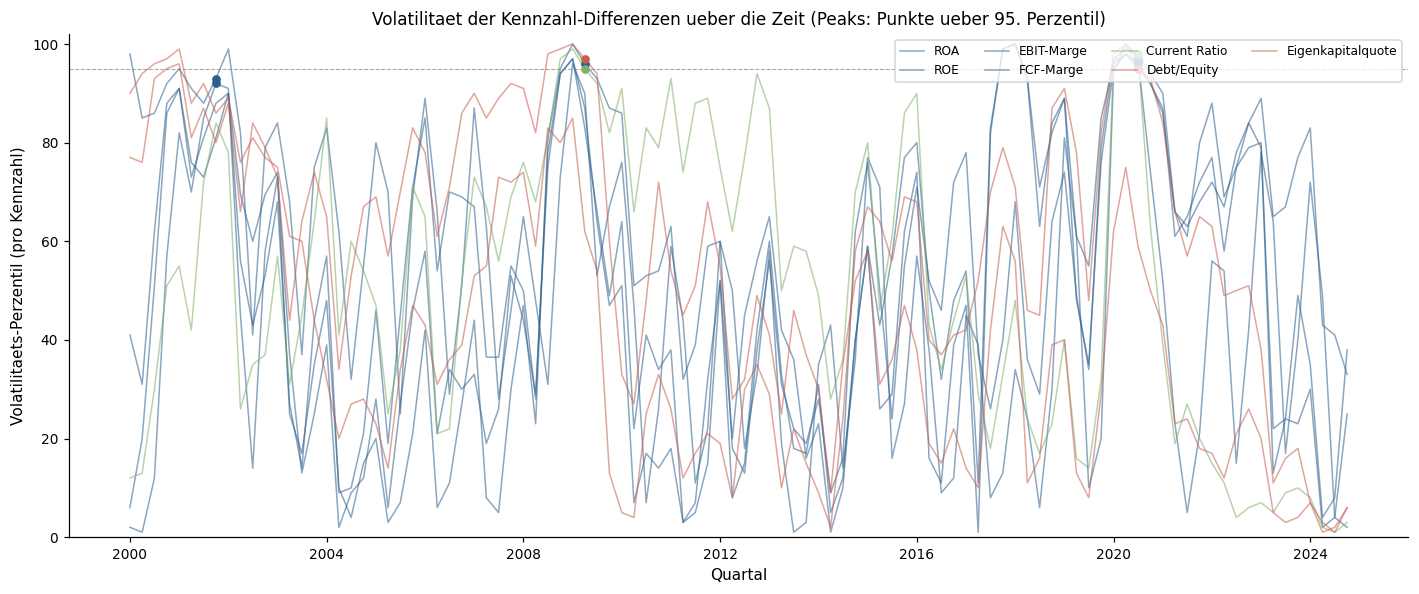

In [22]:
# Plot: Volatilitaet ueber die Zeit, alle 7 Kennzahlen, Peaks markiert
fig, ax = plt.subplots(figsize=(13, 5.5))
for ratio in RATIO_ORDER:
    sub = vol[vol['ratio'] == ratio].sort_values('quarter_dt')
    color = LAYER_COLORS[RATIO_LAYER[ratio]]
    ax.plot(sub['quarter_dt'], sub['vol_percentile'], color=color,
            alpha=0.55, linewidth=1.0, label=RATIO_LABEL[ratio])
    peaks = sub[sub['is_peak']]
    ax.scatter(peaks['quarter_dt'], peaks['vol_percentile'],
                color=color, s=22, zorder=3)
ax.axhline(95, color='gray', linewidth=0.7, linestyle='--', alpha=0.7)
ax.set_ylabel('Volatilitaets-Perzentil (pro Kennzahl)')
ax.set_xlabel('Quartal')
ax.set_title('Volatilitaet der Kennzahl-Differenzen ueber die Zeit '
              '(Peaks: Punkte ueber 95. Perzentil)')
ax.legend(loc='upper right', ncol=4, fontsize=8)
ax.set_ylim(0, 102)
plt.tight_layout()
plt.show()


### 5.2.2 Peak-Windows (Krisenphasen)


In [23]:
# Aggregierte Peak-Quartale: in wievielen Kennzahlen ist das Quartal Peak?
peaks = pd.read_csv(ah._csv('output/explore/peak_windows.csv'))
peaks = peaks.sort_values('mean_percentile', ascending=False).reset_index(drop=True)
peaks['mean_percentile'] = peaks['mean_percentile'].round(1)
peaks


,quarter,n_ratios_peak,mean_percentile
0,2020Q2,6,99.2
1,2009Q1,6,98.2
2,2020Q3,6,96.5
3,2020Q1,6,96.0
4,2008Q4,5,95.8
5,2000Q4,3,94.7
6,2009Q2,4,94.5
7,2001Q1,5,94.4
8,2009Q3,3,93.0
9,2020Q4,4,92.8


### 5.2.3 Quadranten-Reaktionen auf Events


In [24]:
# Median-delta-Y pro Quadrant in den drei Krisenfenstern
win = pd.read_csv(ah._csv('output/explore/window_descriptions.csv'))
win_q = win[win['group_type'] == 'quadrant'].copy()
win_q['quarter_dt'] = pd.PeriodIndex(win_q['quarter_center'], freq='Q').to_timestamp()

events = {
    'Dot-Com (2000Q4)':  ('2000Q4',),
    'GFC (2008Q4-2009Q1)': ('2008Q4', '2009Q1'),
    'COVID (2020Q1-Q2)': ('2020Q1', '2020Q2'),
}
rows = []
for label, qs in events.items():
    sub = win_q[win_q['quarter_center'].isin(qs)]
    pivot = sub.pivot_table(index='ratio', columns='group_value',
                             values='median_dy', aggfunc='median')
    pivot = pivot.reindex(index=[r for r in RATIO_ORDER if r in pivot.index])
    pivot.columns.name = label
    rows.append((label, pivot))

for label, p in rows:
    print(f'== {label} ==')
    display(p.round(4))


== Dot-Com (2000Q4) ==


Dot-Com (2000Q4),KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
ROA,-0.0005,-0.0008,-0.0007,-0.0011
ROE,-0.0009,-0.0036,-0.0022,-0.0027
EBIT_margin,-0.0029,0.0000,-0.0040,0.0000
fcf_margin,-0.0048,-0.0004,-0.0156,0.0000
current_ratio,0.0100,0.0132,0.0083,0.0000
debt_to_equity,-0.0019,0.0012,-0.0027,-0.0007
equity_ratio,0.0004,0.0000,0.0014,0.0000


== GFC (2008Q4-2009Q1) ==


GFC (2008Q4-2009Q1),KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
ROA,-0.0005,-0.0008,-0.0010,-0.0013
ROE,-0.0022,-0.0027,-0.0037,-0.0026
EBIT_margin,0.0001,-0.0009,-0.0056,-0.0106
fcf_margin,0.0046,0.0108,0.0083,0.0179
current_ratio,0.0345,0.0834,0.0449,0.0824
debt_to_equity,-0.0026,-0.0071,-0.0025,0.0005
equity_ratio,0.0017,0.0058,0.0035,0.0038


== COVID (2020Q1-Q2) ==


COVID (2020Q1-Q2),KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
ROA,-0.0002,0.0011,0.0004,0.0005
ROE,-0.0007,0.0004,0.0009,0.0008
EBIT_margin,0.0007,0.0060,0.0029,0.0022
fcf_margin,0.0239,0.0430,0.0284,0.0149
current_ratio,0.0300,0.0542,0.0311,0.0448
debt_to_equity,-0.0011,-0.0052,-0.0023,-0.0002
equity_ratio,0.0002,0.0001,0.0001,0.0006


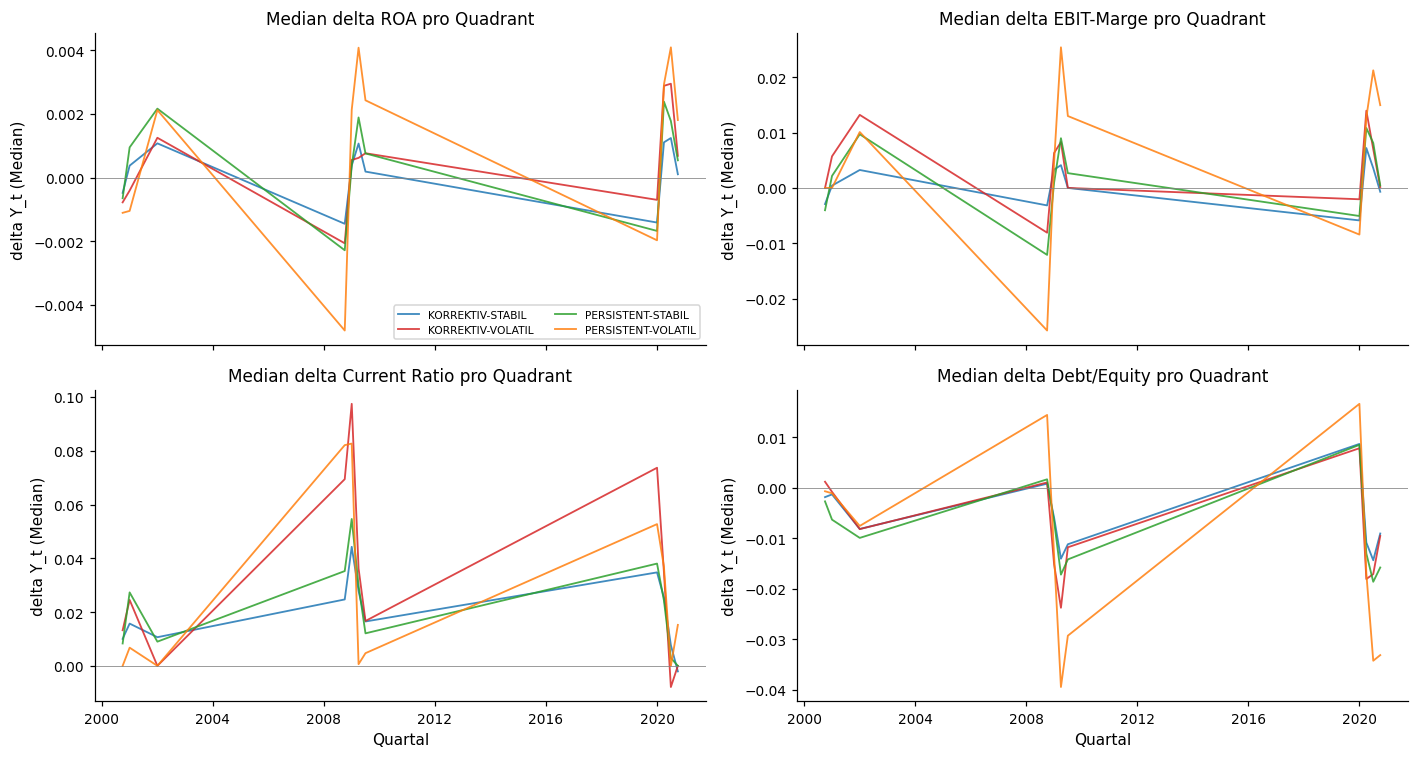

In [25]:
# Plot: Median-delta-Y pro Quadrant ueber die Zeit, Beispiel ROA
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
show_ratios = ['ROA', 'EBIT_margin', 'current_ratio', 'debt_to_equity']
for ax, ratio in zip(axes.flat, show_ratios):
    sub = win_q[win_q['ratio'] == ratio]
    for q in ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL',
               'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']:
        d = sub[sub['group_value'] == q].sort_values('quarter_dt')
        ax.plot(d['quarter_dt'], d['median_dy'], color=QUAD_COLORS[q],
                linewidth=1.2, alpha=0.85, label=q)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'Median delta {RATIO_LABEL[ratio]} pro Quadrant')
    ax.set_ylabel('delta Y_t (Median)')
axes[0, 0].legend(loc='lower right', fontsize=7, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel('Quartal')
plt.tight_layout()
plt.show()


### 5.2.4 Sektorale Reaktionsprofile


In [26]:
# 5.2.4 Sektor-Reaktionen — direkt aus ratio_panel (window_descriptions.csv enthaelt nur Quadrant)
panel = ah.load_ratio_panel()
profiles = ah.load_company_profiles()[['ticker', 'sector']]
panel = panel.merge(profiles, on='ticker', how='left').sort_values(['ticker', 'quarter']).reset_index(drop=True)

# diff1 pro Ticker x Ratio
for r in RATIO_ORDER:
    panel[f'd_{r}'] = panel.groupby('ticker')[r].diff()

events = {
    'Dot-Com 2000Q4-2001Q1':  ['2000Q4', '2001Q1'],
    'GFC 2008Q4-2009Q1':       ['2008Q4', '2009Q1'],
    'COVID 2020Q1-Q2':         ['2020Q1', '2020Q2'],
}

# Pro Krisenfenster: Median delta_Y pro Sektor x Kennzahl
sector_window_tables = {}
for label, qs in events.items():
    sub = panel[panel['quarter'].isin(qs)]
    pivot = sub.groupby('sector')[[f'd_{r}' for r in RATIO_ORDER]].median()
    pivot.columns = [c[2:] for c in pivot.columns]  # 'd_ROA' -> 'ROA'
    pivot = pivot.reindex(index=[s for s in SECTOR_ORDER if s in pivot.index])
    pivot = pivot[[r for r in RATIO_ORDER if r in pivot.columns]]
    pivot.columns.name = label
    sector_window_tables[label] = pivot
    print(f'== {label} ==')
    display(pivot.round(4))


== Dot-Com 2000Q4-2001Q1 ==


Dot-Com 2000Q4-2001Q1,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,-0.0015,-0.0041,-0.0039,-0.0084,0.0142,-0.0047,0.0023
Consumer Cyclical,-0.0016,-0.0058,-0.0055,-0.0075,0.0190,-0.0070,0.0013
Technology,-0.0028,-0.0068,-0.0045,0.0000,0.0368,-0.0013,0.0034
Healthcare,0.0000,-0.0012,0.0000,-0.0122,0.0000,-0.0069,0.0007
Utilities,0.0019,0.0071,-0.0072,0.0208,0.0130,0.0316,-0.0022
Consumer Defensive,-0.0003,0.0000,0.0020,-0.0049,0.0027,0.0000,0.0011
Basic Materials,-0.0027,-0.0075,-0.0123,-0.0176,0.0000,0.0170,-0.0040
Real Estate,-0.0001,-0.0002,-0.0041,0.0001,0.0000,0.0188,-0.0025
Energy,0.0039,0.0087,0.0116,0.0117,0.0000,-0.0097,0.0014


== GFC 2008Q4-2009Q1 ==


GFC 2008Q4-2009Q1,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,-0.0039,-0.0093,-0.0143,-0.0122,0.0559,0.0042,0.0004
Consumer Cyclical,-0.0032,-0.0083,-0.0197,-0.0011,0.0306,0.0075,0.0000
Technology,-0.0037,-0.0074,-0.0137,-0.0033,0.0965,-0.0002,0.0048
Healthcare,0.0000,-0.0003,0.0000,-0.0107,0.0327,0.0000,0.0002
Utilities,0.0005,0.0014,-0.0036,0.0704,0.0343,0.0078,-0.0022
Consumer Defensive,-0.0000,0.0000,0.0011,-0.0017,0.0310,0.0001,-0.0001
Basic Materials,-0.0063,-0.0127,-0.0319,-0.0066,0.0874,0.0015,0.0067
Real Estate,-0.0003,-0.0006,-0.0170,0.0489,0.0000,0.0087,-0.0009
Energy,-0.0071,-0.0160,-0.0258,-0.0041,0.0188,0.0065,0.0009


== COVID 2020Q1-Q2 ==


COVID 2020Q1-Q2,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,-0.0022,-0.0046,-0.0056,0.0238,0.0395,0.0046,-0.0031
Consumer Cyclical,-0.0061,-0.0164,-0.0214,-0.0111,0.0454,0.0439,-0.0063
Technology,-0.0002,-0.0008,-0.0008,0.0098,0.0295,0.0000,-0.0024
Healthcare,-0.0006,-0.0017,0.0000,0.0141,0.0451,0.0000,0.0002
Utilities,0.0011,0.0043,0.0197,0.0562,0.0472,0.0144,-0.0018
Consumer Defensive,-0.0003,-0.0009,0.0001,0.0355,0.0344,-0.0004,-0.0001
Basic Materials,0.0011,0.0017,0.0048,0.0061,0.0462,0.0071,-0.0033
Real Estate,-0.0022,-0.0037,-0.0234,0.0033,0.1322,0.0331,-0.0061
Energy,-0.0051,-0.0154,-0.0823,0.0061,0.0325,0.0287,-0.0060


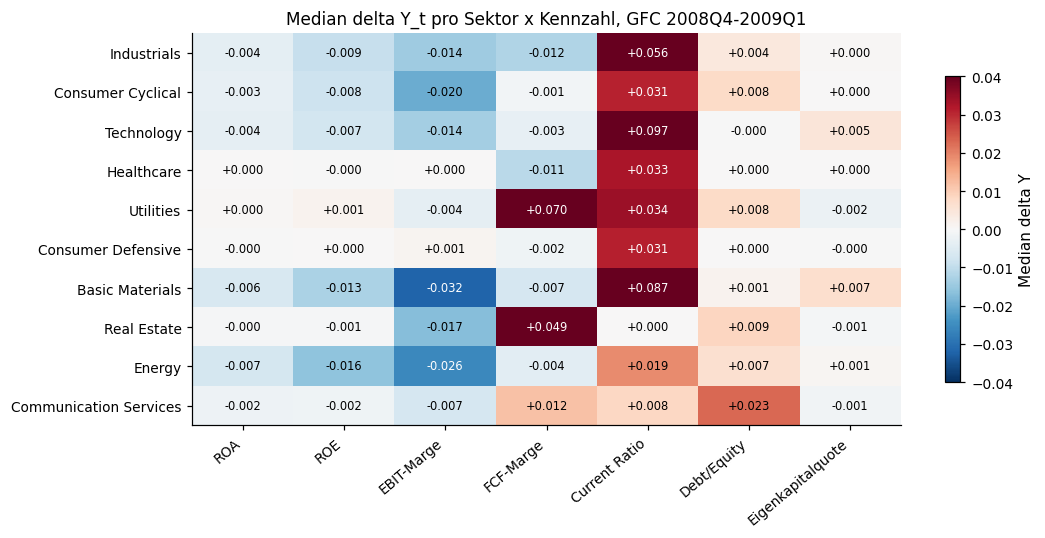

Sektor-Reaktionen pro Krise (Median |delta Y| ueber alle 7 Kennzahlen):


,Dot-Com 2000Q4-2001Q1,GFC 2008Q4-2009Q1,COVID 2020Q1-Q2
sector,,,
Basic Materials,0.0075,0.0067,0.0048
Communication Services,0.0075,0.0068,0.0084
Consumer Cyclical,0.0058,0.0075,0.0164
Consumer Defensive,0.0011,0.0001,0.0004
Energy,0.0087,0.0071,0.0154
Healthcare,0.0007,0.0002,0.0006
Industrials,0.0041,0.0093,0.0046
Real Estate,0.0002,0.0009,0.0061
Technology,0.0034,0.0048,0.0008


In [27]:
# Heatmap: Sektor x Kennzahl Median-delta-Y in der GFC
p_gfc = sector_window_tables['GFC 2008Q4-2009Q1']
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(p_gfc, cmap='RdBu_r', vmin=-0.04, vmax=0.04, aspect='auto')
ax.set_xticks(range(len(p_gfc.columns)))
ax.set_yticks(range(len(p_gfc.index)))
ax.set_xticklabels([RATIO_LABEL[r] for r in p_gfc.columns], rotation=40, ha='right')
ax.set_yticklabels(p_gfc.index)
for i in range(len(p_gfc.index)):
    for j in range(len(p_gfc.columns)):
        v = p_gfc.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center',
                    fontsize=7.5, color='black' if abs(v) < 0.025 else 'white')
ax.set_title('Median delta Y_t pro Sektor x Kennzahl, GFC 2008Q4-2009Q1')
fig.colorbar(im, ax=ax, shrink=0.78, label='Median delta Y')
plt.tight_layout()
plt.show()

# Zusatz: Sektor-Ranking nach |delta_Y| aggregiert ueber alle Kennzahlen
print('Sektor-Reaktionen pro Krise (Median |delta Y| ueber alle 7 Kennzahlen):')
ranks = {}
for label, p in sector_window_tables.items():
    abs_med = p.abs().median(axis=1).sort_values(ascending=False)
    ranks[label] = abs_med
ranks_df = pd.DataFrame(ranks).round(4)
display(ranks_df)


---
## 5.3 Halbperioden-Stabilitaet (Re-Use FF1 E5.1)

Erst in FF2 wird die Frage relevant, ob die Querschnitts-Korrelationen robust ueber die Zeit sind. Dazu wird das Panel in zwei Haelften (2000Q1-2012Q4 und 2013Q1-2024Q4) geteilt und phi1 pro Ticker x Kennzahl in beiden Haelften neu geschaetzt. Wilcoxon-Vorzeichen-Rang-Test pruefst die Verteilungsverschiebung.


In [28]:
# Halbperioden-Vergleich aus FF1 E5.1
halfsum = pd.read_csv(ah._csv('output/ar/ar_subperiod_summary.csv'))
halfsum = halfsum.set_index('ratio').reindex(
    [r for r in RATIO_ORDER if r in halfsum['ratio'].values]
    if 'ratio' in halfsum.columns else RATIO_ORDER
).reset_index() if 'ratio' in halfsum.reset_index().columns else halfsum
halfsum.round(4)


,ratio,n,phi1_median_pre,phi1_median_post,diff_median,wilcoxon_W,wilcoxon_p
0,ROA,932,-0.4027,-0.4392,-0.0418,170361.0,0.0000
1,ROE,932,-0.4000,-0.4354,-0.0428,170358.0,0.0000
2,EBIT_margin,932,-0.4143,-0.4108,-0.0056,208526.0,0.3062
3,fcf_margin,932,-0.4611,-0.4465,0.0128,201737.0,0.0569
4,current_ratio,932,-0.1662,-0.1881,-0.0209,199357.0,0.0283
5,debt_to_equity,909,-0.0754,-0.0960,-0.0160,199071.0,0.3292
6,equity_ratio,932,-0.0444,-0.0405,0.0114,210454.0,0.3989


In [29]:
# Detail-Daten: phi1 vor vs. nach Halbperiode pro Ticker x Ratio
halfdet = pd.read_csv(ah._csv('output/ar/ar_subperiod_comparison.csv'))
print(f'Halbperioden-Daten: {len(halfdet)} Schaetzungen')
halfdet.head()


Halbperioden-Daten: 6524 Schaetzungen


,ticker,ratio,phi1_pre,phi1_post,sigma_pre,sigma_post,n_pre,n_post,phi1_diff
0,A,ROA,-0.560733,-0.482979,0.031245,0.016267,51,47,0.077754
1,A,ROE,-0.529320,-0.477815,0.150619,0.030168,51,47,0.051506
2,A,EBIT_margin,-0.384169,-0.538817,0.176028,0.081283,51,47,-0.154647
3,A,fcf_margin,-0.640136,-0.728693,0.282980,0.118159,51,47,-0.088557
4,A,current_ratio,-0.050656,0.075454,0.441918,0.356814,51,47,0.126110


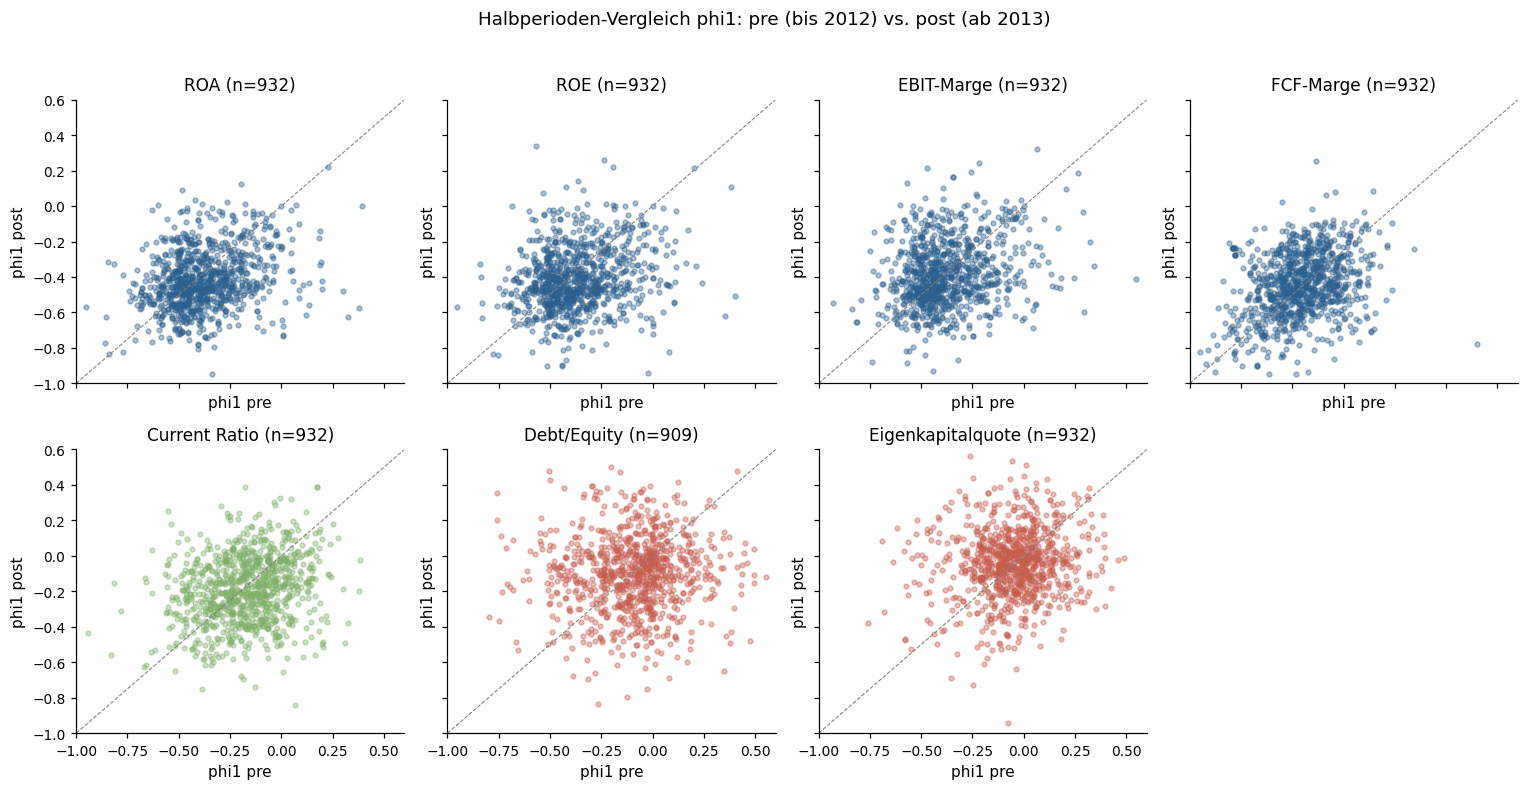

In [30]:
# Plot: phi1 pre vs. post pro Kennzahl
fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
for ax, ratio in zip(axes.flat, RATIO_ORDER):
    sub = halfdet[halfdet['ratio'] == ratio].dropna(subset=['phi1_pre', 'phi1_post'])
    color = LAYER_COLORS[RATIO_LAYER[ratio]]
    ax.scatter(sub['phi1_pre'], sub['phi1_post'], color=color, alpha=0.4, s=10)
    lim = (-1.0, 0.6)
    ax.plot(lim, lim, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f'{RATIO_LABEL[ratio]} (n={len(sub)})')
    ax.set_xlabel('phi1 pre')
    ax.set_ylabel('phi1 post')
axes[1, 3].axis('off')
plt.suptitle('Halbperioden-Vergleich phi1: pre (bis 2012) vs. post (ab 2013)',
              y=1.02)
plt.tight_layout()
plt.show()


---
## 5.4 Interpretation (Vier-Achsen-Modell)

Re-Use des Vier-Achsen-Modells aus Kap. 4.3. Die in 5.1 beobachteten Cluster (Profitabilitaets-Block ROA/ROE/EBIT/FCF; Kapitalstruktur-Block Debt/Equity / Eigenkapitalquote; Liquiditaets-Sonderstellung Current Ratio) sind direkte Konsequenz der Achsen 1, 3 und 4 (Markt/Management, Strom/Bestand, Zaehler/Nenner). Die Krisen-Reaktionen aus 5.2 testen Achse 2 (Zeitkonstante): korrektive Quadranten reagieren staerker auf Schocks, persistente Quadranten halten ihre Trends auch durch Krisenphasen hindurch.

Weitere Interpretation erfolgt im Fliesstext der Arbeit (Kap. 5.4).


---
## 5.5 Erkenntnisse aus FF2

Erkenntnis-Bullet-Points werden im Fliesstext zusammengefasst, sobald 5.1.5 (Lead-Lag) und die finalen Werte aus 5.1.4 (Sektor-Spearman) in den Text uebernommen sind.


---
## 5.6 Robustheit

Robustheits-Checks fuer FF2 (Pearson- vs. Spearman-Vergleich, Sub-Sample ohne Crash-Quartale, alternative Quadranten-Schwellen) werden in einer Folgesession ergaenzt.
